In [ ]:
(1, 3)
(2, 5)
(3, 7)
(4, 9)

((1,1), 3)
((1,2), 5)
((1,3), 7)
((1,4), 9)

f(x) = f(x0, x1) = 2 * x1 + 1 = 2 * x1 + 1 * x0

f_w(x) = w * x
loss = (f_w(x) - y )^2
loss_prim = 2 *(f_w(x) - y) * f_w_prim(x) 
          = 2 *(f_w(x) - y) * (w * x - y)' 
         = 2 *(f_w(x) - y) * x

loss = abs(f_w(x) - y )
loss_prim = 


X^(-1)  = 1 / det(X) * adj(X)

n -> 0
1 / n  -> 1 / (n + eps)

det(X) = 0?

(1, 2, 3), 6
(2, 5, 1), 5
(1, 2, 3), 6
(3, 6, 9), 6
(3, 2, 1), 3
(4, 7, 7), 5
(5, 6, 2), 1




IndentationError: unindent does not match any outer indentation level (<tokenize>, line 17)

In [ ]:
(1, 2)
(2, 5)
(3, 10)
(4, 17)
(5, 26)

In [ ]:
(1, 4)
(2, 7)
(3, 10)
(4, 14)
(5, 16)

In [ ]:
(1, 3)
(2, 6)
(3, 12)
(4, 24)

In [ ]:
import numpy as np

In [ ]:
############################################################
# Optimization algorithm
noEpochs = 10

def phi(x):
    return np.array([1, x])

def gradientDescent(examples):
    w = np.zeros(2)
    eta = 0.1
    for t in range(noEpochs):
        lossValue = 1.0 / len(examples) * sum((w.dot(phi(x)) - y)**2 for x, y in examples)
        gradValue = 1.0 / len(examples) * sum(2 * (w.dot(phi(x)) - y) * phi(x) for x, y in examples)
        w = w - eta * gradValue
        # print(f'epoch {t}: w = {w}, Loss(w) = {lossValue}, gradientLoss = {gradValue}')
        yield t, lossValue
    

def stochasticGradientDescent(examples):
    w = np.zeros(2)
    eta = 0.1
    for t in range(noEpochs):
        for i in range(len(examples)):
            x, y = examples[i]
            lossValue = (w.dot(phi(x)) - y)**2
            gradValue = 2 * (w.dot(phi(x)) - y) * phi(x) 
            # print(f'iter {i}: w = {w}')
            w = w - eta * gradValue
        # print(f'epoch {t}: w = {w}, Loss(w) = {lossValue}, gradientLoss = {gradValue}')
        yield t, lossValue

In [ ]:
import matplotlib.pyplot as plt

def lossPlot(history):
    epochs, losses = zip(*history)
    plt.figure(figsize=(4, 3))   # width, height in inches, make it smaller
    plt.plot(epochs, losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Evolution')
    plt.show()

In [ ]:
trainExamples1 = [
    (1, 2),
    (2, 1),
    (4, 5),
]

In [ ]:
trueW = np.array([3])
def generate(noExamples=100):
    examples = []
    for _ in range(noExamples):
        x = np.random.normal(0,1)
        y = trueW.dot(x) + np.random.randn()
        examples.append((x, y[0]))
    return examples
    
def generateWithOutliers(noExamples=100):
    examples = generate(noExamples)
    examples = [list(example) for example in examples]
    for _ in range(5):
        pos = np.random.randint(0, len(examples))
        examples[pos][1] += 100
    return examples

trainExamples2 = generate(100)
trainExamples3 = generate(1000)
trainExamples4= generateWithOutliers(100)


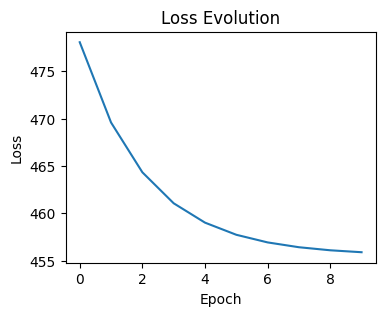

In [98]:
history = list(gradientDescent(trainExamples4))  # [(t0, loss0), (t1, loss1), ...]
lossPlot(history)


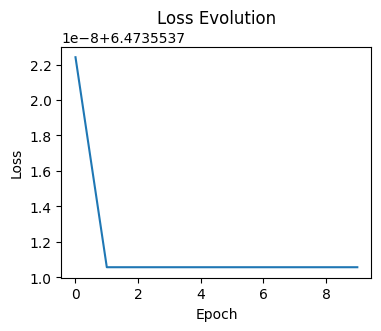

In [102]:
history = list(stochasticGradientDescent(trainExamples4))  # [(t0, loss0), (t1, loss1), ...]
lossPlot(history)